In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import random
import warnings
warnings.simplefilter('ignore')

# Data inladen
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Class names voor Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# NORMALISATIE: Piksels schalen naar 0 - 1
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"✅ Data is geladen en genormaliseerd! Train shape: {X_train.shape}")

✅ Data is geladen en genormaliseerd! Train shape: (60000, 28, 28)


In [2]:
# 10 verschillende experimenten definiëren
experiments = [
    {'id': 1, 'layers': 1, 'nodes': [32], 'epochs': 5, 'batch': 32, 'lr': 0.001, 'note': 'Shallow Baseline'},
    {'id': 2, 'layers': 1, 'nodes': [128], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Wider Shallow'},
    {'id': 3, 'layers': 2, 'nodes': [64, 32], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': '2 Layers Baseline'},
    {'id': 4, 'layers': 2, 'nodes': [128, 64], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Wider 2 Layers'},
    {'id': 5, 'layers': 3, 'nodes': [128, 64, 32], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Deep Network'},
    {'id': 6, 'layers': 3, 'nodes': [256, 128, 64], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Very Deep & Wide'},
    {'id': 7, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 128, 'lr': 0.001, 'note': 'Larger Batch Size'},
    {'id': 8, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 32, 'lr': 0.01, 'note': 'High Learning Rate'},
    {'id': 9, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 32, 'lr': 0.0001, 'note': 'Low Learning Rate'},
    {'id': 10, 'layers': 3, 'nodes': [256, 128, 64], 'epochs': 30, 'batch': 64, 'lr': 0.001, 'note': 'Max Power'}
]

results = []
print("🔥 Experimenten gestart (Dit kan even duren met afbeeldingen)...\n")

for exp in experiments:
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28))) # Afbeelding platmaken (28x28 = 784 pixels)
    
    for i in range(exp['layers']):
        model.add(Dense(exp['nodes'][i], activation='relu'))
            
    # Output laag voor 10 kledingstukken
    model.add(Dense(10, activation='softmax'))
    
    optimizer = Adam(learning_rate=exp['lr'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Layers': exp['layers'],
        'Epochs': exp['epochs'],
        'Accuracy': round(accuracy, 4)
    })
    print(f"✅ Experiment {exp['id']} voltooid! ({exp['note']}) -> Accuracy: {accuracy*100:.2f}%")

df_results = pd.DataFrame(results)
print("\n🏆 ALLE EXPERIMENTEN AFGEROND!")
display(df_results)

🔥 Experimenten gestart (Dit kan even duren met afbeeldingen)...

✅ Experiment 1 voltooid! (Shallow Baseline) -> Accuracy: 85.89%
✅ Experiment 2 voltooid! (Wider Shallow) -> Accuracy: 88.53%
✅ Experiment 3 voltooid! (2 Layers Baseline) -> Accuracy: 87.46%
✅ Experiment 4 voltooid! (Wider 2 Layers) -> Accuracy: 88.97%
✅ Experiment 5 voltooid! (Deep Network) -> Accuracy: 88.42%
✅ Experiment 6 voltooid! (Very Deep & Wide) -> Accuracy: 88.46%
✅ Experiment 7 voltooid! (Larger Batch Size) -> Accuracy: 87.93%
✅ Experiment 8 voltooid! (High Learning Rate) -> Accuracy: 85.41%
✅ Experiment 9 voltooid! (Low Learning Rate) -> Accuracy: 86.32%
✅ Experiment 10 voltooid! (Max Power) -> Accuracy: 89.34%

🏆 ALLE EXPERIMENTEN AFGEROND!


,Experiment ID,Description,Layers,Epochs,Accuracy
0,1,Shallow Baseline,1,5,0.8589
1,2,Wider Shallow,1,10,0.8853
2,3,2 Layers Baseline,2,10,0.8746
3,4,Wider 2 Layers,2,20,0.8897
4,5,Deep Network,3,20,0.8842
5,6,Very Deep & Wide,3,20,0.8846
6,7,Larger Batch Size,2,10,0.8793
7,8,High Learning Rate,2,10,0.8541
8,9,Low Learning Rate,2,10,0.8632
9,10,Max Power,3,30,0.8934


FINAAL MODEL TRAINING (Max Power)
Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8236 - loss: 0.4969
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8666 - loss: 0.3645
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8790 - loss: 0.3285
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8878 - loss: 0.3027
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8932 - loss: 0.2857
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8987 - loss: 0.2720
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9026 - loss: 0.2588
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9058 - loss: 0.2484
Epoch 9/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9097 - loss: 0.2402
Epoch 10/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9138 - loss: 0.2281
Epoch 11/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9162 - loss: 0.2197
Epoch 12/30
938/93

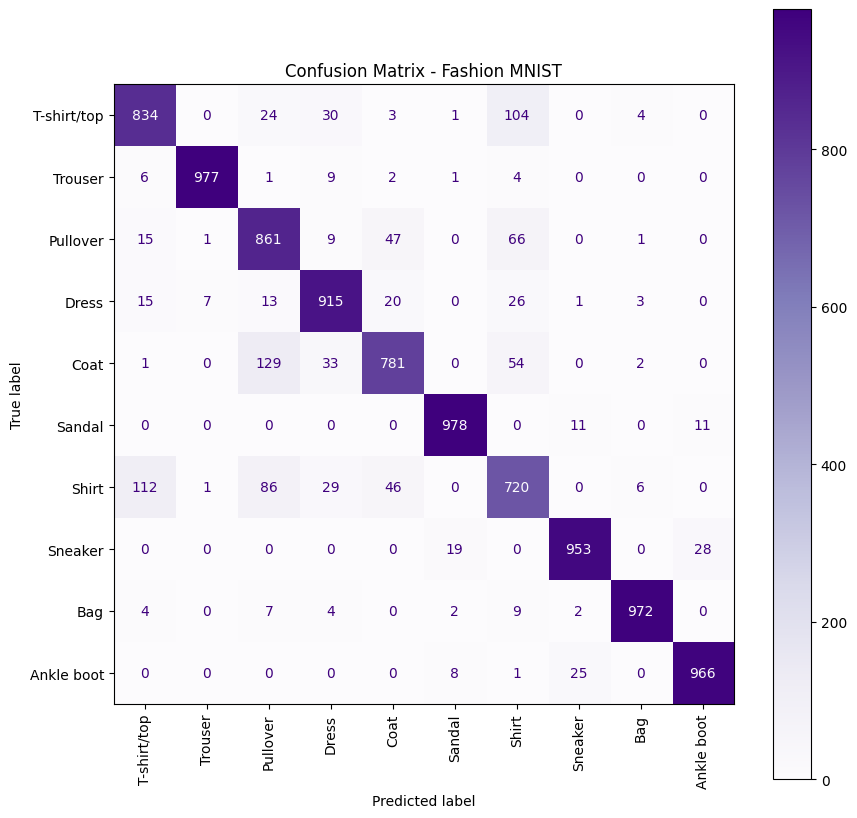

In [3]:
print("="*50, "\nFINAAL MODEL TRAINING (Max Power)\n", "="*50)

model_final = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_final.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model_final.fit(X_train, y_train, epochs=30, batch_size=64, verbose=1)

y_pred_probs = model_final.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_labels, target_names=class_names))

# Grote Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels, display_labels=class_names, cmap='Purples', ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix - Fashion MNIST")
plt.show()

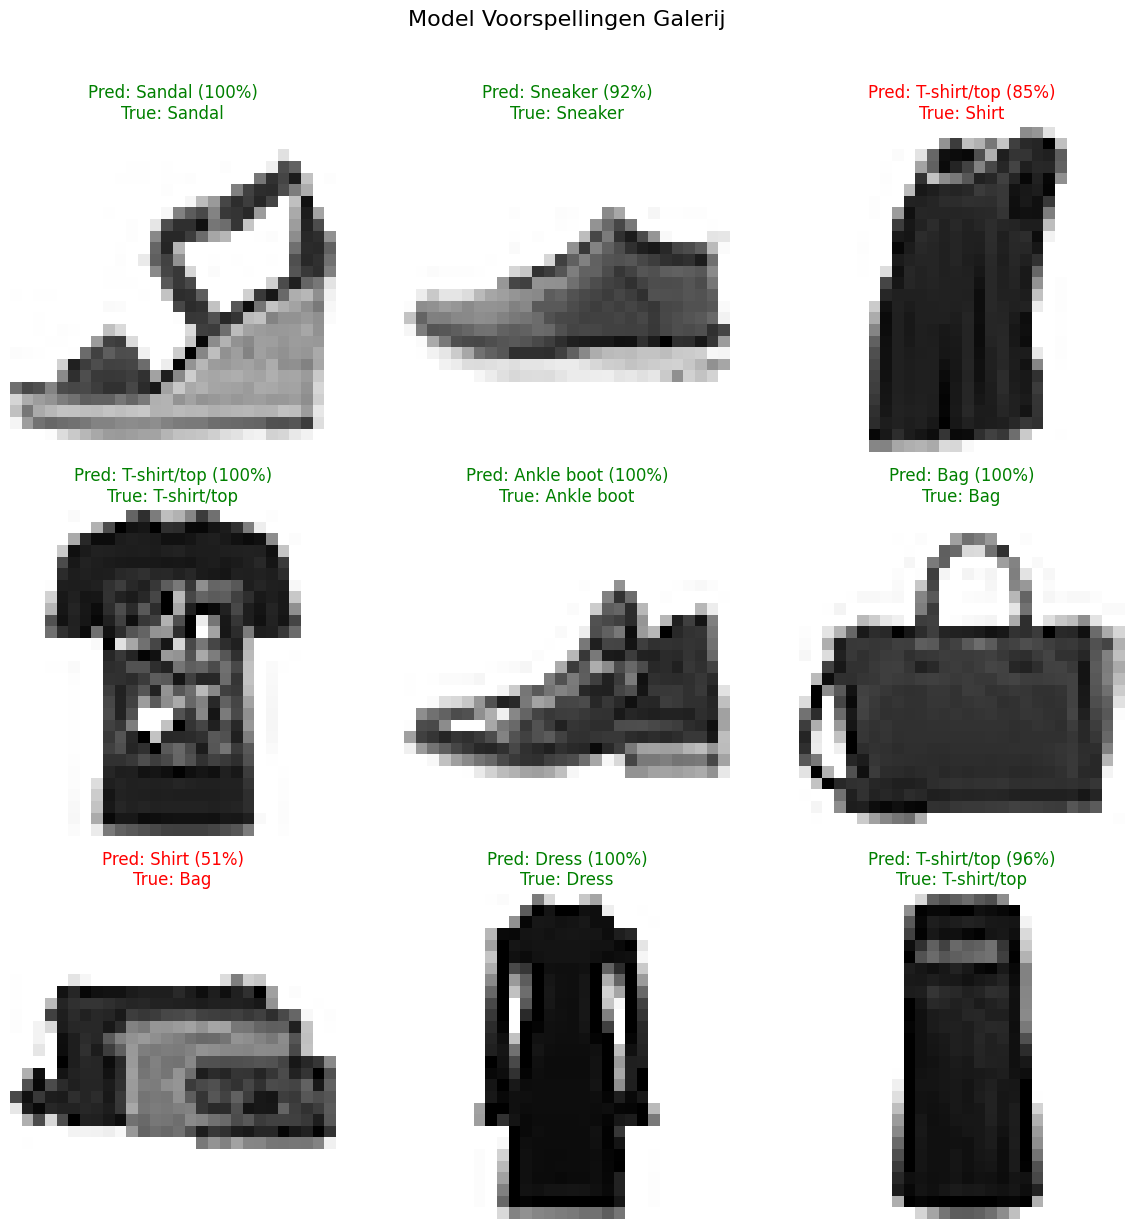

In [4]:
# 3x3 Grid met willekeurige voorspellingen
plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    
    # Kies een random afbeelding
    rand_index = random.randint(0, len(X_test) - 1)
    img = X_test[rand_index]
    true_label = y_test[rand_index]
    
    # Model laten voorspellen
    pred_probs = model_final.predict(img.reshape(1, 28, 28), verbose=0)
    pred_label = np.argmax(pred_probs)
    
    # Afbeelding tonen
    plt.imshow(img, cmap=plt.cm.binary)
    
    # Kleur bepalen (Groen = Goed, Rood = Fout)
    if pred_label == true_label:
        color = 'green'
    else:
        color = 'red'
        
    plt.title(f"Pred: {class_names[pred_label]} ({100*np.max(pred_probs):.0f}%)\nTrue: {class_names[true_label]}", color=color)
    plt.axis('off')

plt.suptitle("Model Voorspellingen Galerij", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from IPython.display import display

# 10 Different Hyperparameter Configurations for Fashion MNIST
experiments = [
    {'id': 1, 'layers': 1, 'nodes': [128], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Baseline Model'},
    {'id': 2, 'layers': 1, 'nodes': [128], 'epochs': 30, 'batch': 32, 'lr': 0.001, 'note': 'More Epochs'},
    {'id': 3, 'layers': 2, 'nodes': [128, 64], 'epochs': 15, 'batch': 32, 'lr': 0.001, 'note': 'Deeper Network (2 Hidden)'},
    {'id': 4, 'layers': 2, 'nodes': [256, 128], 'epochs': 15, 'batch': 32, 'lr': 0.001, 'note': 'Wider & Deeper Network'},
    {'id': 5, 'layers': 3, 'nodes': [256, 128, 64], 'epochs': 20, 'batch': 64, 'lr': 0.001, 'note': 'Very Deep Network'},
    {'id': 6, 'layers': 2, 'nodes': [128, 64], 'epochs': 15, 'batch': 128, 'lr': 0.001, 'note': 'Large Batch Size (Fast)'},
    {'id': 7, 'layers': 2, 'nodes': [128, 64], 'epochs': 15, 'batch': 32, 'lr': 0.01, 'note': 'High Learning Rate'},
    {'id': 8, 'layers': 2, 'nodes': [128, 64], 'epochs': 20, 'batch': 32, 'lr': 0.0001, 'note': 'Low Learning Rate (Slow & Steady)'},
    {'id': 9, 'layers': 1, 'nodes': [32], 'epochs': 15, 'batch': 32, 'lr': 0.001, 'note': 'Small Sized Network'},
    {'id': 10, 'layers': 2, 'nodes': [512, 256], 'epochs': 30, 'batch': 64, 'lr': 0.001, 'note': 'Max Power (Heavy Model)'}
]

results = []
print(" Fashion MNIST Experiments started\n")

for exp in experiments:
    model = Sequential()
    
    # IMPORTANT: We must flatten the 28x28 image arrays into a 1D array (784 pixels)
    model.add(Flatten(input_shape=(28, 28)))
    
    # Add hidden layers dynamically
    for i in range(exp['layers']):
        model.add(Dense(exp['nodes'][i], activation='relu'))
    
    # Output layer: 10 neurons (for 10 classes) and 'softmax' activation
    model.add(Dense(10, activation='softmax'))
    
    # Compile the model
    optimizer = Adam(learning_rate=exp['lr'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    # Train the model silently
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    
    # Evaluate with Test Data
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Save results
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Layers': exp['layers'],
        'Nodes': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Batch Size': exp['batch'],
        'Learning Rate': exp['lr'],
        'Accuracy': round(accuracy, 4)
    })
    print(f"✅ Experiment {exp['id']} completed! ({exp['note']}) -> Accuracy: {accuracy*100:.2f}%")

# Save and Display
df_results = pd.DataFrame(results)
df_results.to_csv('Fashion_MNIST_Experiment_Results.csv', index=False, sep=';')
print("\n ALL EXPERIMENTS COMPLETED.")
display(df_results)

 Fashion MNIST Experiments started

✅ Experiment 1 completed! (Baseline Model) -> Accuracy: 88.33%
✅ Experiment 2 completed! (More Epochs) -> Accuracy: 88.89%
✅ Experiment 3 completed! (Deeper Network (2 Hidden)) -> Accuracy: 88.92%
✅ Experiment 4 completed! (Wider & Deeper Network) -> Accuracy: 89.20%
✅ Experiment 5 completed! (Very Deep Network) -> Accuracy: 89.63%
✅ Experiment 6 completed! (Large Batch Size (Fast)) -> Accuracy: 88.35%
✅ Experiment 7 completed! (High Learning Rate) -> Accuracy: 83.95%
✅ Experiment 8 completed! (Low Learning Rate (Slow & Steady)) -> Accuracy: 88.13%
✅ Experiment 9 completed! (Small Sized Network) -> Accuracy: 87.19%
✅ Experiment 10 completed! (Max Power (Heavy Model)) -> Accuracy: 89.50%

 ALL EXPERIMENTS COMPLETED.


,Experiment ID,Description,Layers,Nodes,Epochs,Batch Size,Learning Rate,Accuracy
0,1,Baseline Model,1,[128],10,32,0.0010,0.8833
1,2,More Epochs,1,[128],30,32,0.0010,0.8889
2,3,Deeper Network (2 Hidden),2,"[128, 64]",15,32,0.0010,0.8892
3,4,Wider & Deeper Network,2,"[256, 128]",15,32,0.0010,0.8920
4,5,Very Deep Network,3,"[256, 128, 64]",20,64,0.0010,0.8963
5,6,Large Batch Size (Fast),2,"[128, 64]",15,128,0.0010,0.8835
6,7,High Learning Rate,2,"[128, 64]",15,32,0.0100,0.8395
7,8,Low Learning Rate (Slow & Steady),2,"[128, 64]",20,32,0.0001,0.8813
8,9,Small Sized Network,1,[32],15,32,0.0010,0.8719
9,10,Max Power (Heavy Model),2,"[512, 256]",30,64,0.0010,0.8950


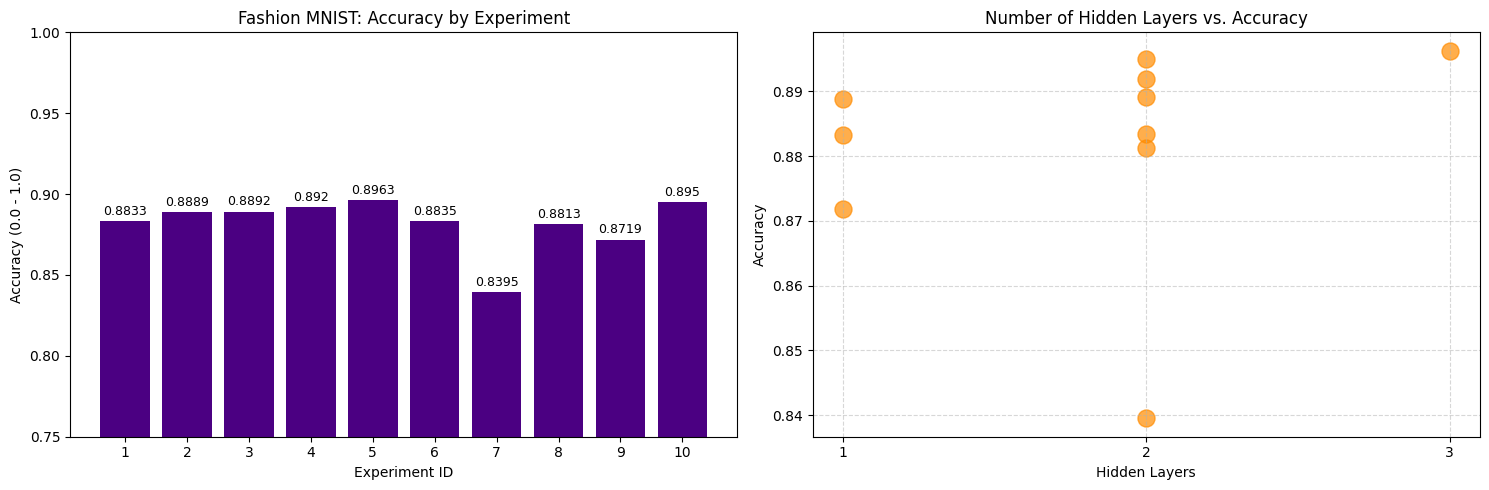

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy Comparison
ax1.bar(df_results['Experiment ID'].astype(str), df_results['Accuracy'], color='indigo')
ax1.set_title('Fashion MNIST: Accuracy by Experiment')
ax1.set_xlabel('Experiment ID')
ax1.set_ylabel('Accuracy (0.0 - 1.0)')
ax1.set_ylim(0.75, 1.0) 
for i, v in enumerate(df_results['Accuracy']):
    ax1.text(i, v + 0.002, str(v), ha='center', va='bottom', fontsize=9)

# Plot 2: Layers vs Accuracy
ax2.scatter(df_results['Layers'], df_results['Accuracy'], color='darkorange', s=150, alpha=0.7)
ax2.set_title('Number of Hidden Layers vs. Accuracy')
ax2.set_xlabel('Hidden Layers')
ax2.set_ylabel('Accuracy')
ax2.set_xticks([1, 2, 3])
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()